# Exercise 02: Multilayer Perceptrons

Course: Introduction to Deep Learning

This notebook is a structured template for Sheet 02. Fill in each `TODO` section with your answers and implementations.

## Task 1: Theory Questions

Write your answers directly in the markdown cells below.

### 1.1 Activations & Nonlinearity

**TODO:** Write down the formulas for sigmoid and ReLU.

**TODO:** State the output range of each activation.

**TODO:** Explain whether a network with only linear activations can learn non-linear decision boundaries, and why.

### 1.2 Computational Graphs & Backpropagation

**TODO:** Add or draw the computational graph for a one-hidden-layer MLP: `x -> z^(1) -> a^(1) -> z^(2) -> y_hat`.

**TODO:** Label the dimensions of weights and activations for input size `d`, hidden size `h`, and one output.

**TODO:** Explain the role of:
- `(W^(l))^T`
- `phi'(z^(l-1))` in the element-wise product
- the outer product `delta^(l) (a^(l-1))^T`

### 1.3 Regularization

**TODO:** Explain early stopping and what to look for in training and validation curves.

**TODO:** Explain how dropout behaves during training versus inference.

**TODO:** Write the L2-regularized loss function and explain how `lambda` affects the weights.

### 1.4 Mini-batch Learning

**TODO:** Explain the difference between batch gradient descent, mini-batch gradient descent, and stochastic gradient descent.

**TODO:** Define an epoch.

**TODO:** For 10,000 training examples and batch size 250, compute the number of parameter updates per epoch.

## Task 2: MLP from Scratch

Learning objectives:
- Implement forward and backward pass manually in NumPy
- Understand backpropagation mechanics
- Optional: verify correctness via gradient checking

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

np.random.seed(42)

### 2.1 Activation Functions

In [2]:
def relu(z):
    return np.maximum(0,z)


def relu_derivative(z):
    return (z > 0).astype(float)


def sigmoid(z):
    return 1 / (1 + np.exp(-z))


def sigmoid_derivative(z):
    return sigmoid(z)*(1- sigmoid(z))

### 2.2 MLP Class

In [3]:
class MLPFromScratch:
    def __init__(self, layer_sizes):
        """Initialize MLP with given layer sizes, e.g. [2, 32, 16, 1].
        Use small random initialization (scale 0.1) for weights and zeros for biases.
        """
        # TODO: Create lists for weights and biases
        # TODO: Initialize weights with small random values
        # TODO: Initialize biases with zeros
        self.layer_sizes = layer_sizes
        self.weights = []
        self.biases = []
        self.cache = {}
        
        for layer_index in range(len(layer_sizes)-1):
            w = 0.1 * np.random.randn(layer_sizes[layer_index], layer_sizes[layer_index+1])
            b = np.zeros((1,layer_sizes[layer_index+1]))

            self.weights.append(w)
            self.biases.append(b)

    def forward(self, X):
        """Forward pass. Store intermediate values for backprop.

        Args:
            X: Input, shape (N, D).

        Returns:
            Output, shape (N, 1).
        """
        # TODO: Apply affine layers + ReLU in hidden layers + sigmoid in output layer
        # TODO: Store intermediate activations and pre-activations in self.cache
        self.cache["a_0"] = X
        for layer_index in range(len(self.layer_sizes)-1):
            X = np.dot(X, self.weights[layer_index]) + self.biases[layer_index]
            self.cache[f"z_{layer_index+1}"] = X
            if layer_index < len(self.layer_sizes) - 2:
                X = relu(X)
                self.cache[f"a_{layer_index+1}"] = X
            else:
                X = sigmoid(X)
                self.cache[f"a_{layer_index+1}"] = X
        return X

    def compute_loss(self, y_true, y_pred):
        """Binary cross-entropy loss."""
        eps = 1e-15
        # for the case if y_pred is 0 or 1
        y_pred = np.clip(y_pred, eps, 1 - eps)
        loss = -(y_true*np.log(y_pred)
                 +(1-y_true)*np.log(1-y_pred))
        return np.mean(loss)

    def backward(self, y_true):
        """Backward pass. Compute gradients for all weights and biases.

        Args:
            y_true: True labels, shape (N, 1).

        Returns:
            dW: List of weight gradients.
            db: List of bias gradients.
        """
        N = y_true.shape[0]

        dW = [None] * len(self.weights)

        db = [None] * len(self.biases)

        y_pred = self.cache[f"a_{len(self.weights)}"]

        dz = y_pred - y_true  # output error for sigmoid + BCE

        for layer_index in reversed(range(len(self.weights))):
            a_prev = self.cache[f"a_{layer_index}"]

            dW[layer_index] = a_prev.T @ dz / N 
            db[layer_index] = np.sum(dz, axis=0, keepdims=True) / N

            if layer_index > 0:
                dz = np.dot(dz, self.weights[layer_index].T)
                dz = dz * relu_derivative(self.cache[f"z_{layer_index}"])

        return dW, db
            
            

    def train_step(self, X, y, lr=0.1):
        """One forward + backward pass with parameter update."""
        # TODO: Forward pass
        # TODO: Compute loss
        # TODO: Backward pass
        # TODO: Update parameters with gradient descent
        y_pred = self.forward(X)
        loss = self.compute_loss(y, y_pred)
        print(f"The loss in the iteration is {loss}")

        dW, db = self.backward(y)

        # self.weights = self.weights - lr * dW
        # self.biases = self.biases - lr * db
        for index in range(len(self.weights)):
            self.weights[index] = self.weights[index] - lr * dW[index]
            self.biases[index] = self.biases[index] - lr * db[index]
        return loss

### 2.3 Train on Moons Dataset

The loss in the iteration is 0.6913324663766887
Epoch 0, train loss: 0.6913, test loss: 0.6895, train acc: 0.5650, test acc: 0.6600
The loss in the iteration is 0.6909108975202517
The loss in the iteration is 0.690477583282021
The loss in the iteration is 0.690035628116282
The loss in the iteration is 0.6895832744782424
The loss in the iteration is 0.6891244490375285
The loss in the iteration is 0.6886600420201389
The loss in the iteration is 0.6881894570982355
The loss in the iteration is 0.6877142680136972
The loss in the iteration is 0.6872339910933573
The loss in the iteration is 0.6867531742043482
Epoch 10, train loss: 0.6868, test loss: 0.6853, train acc: 0.7275, test acc: 0.7800
The loss in the iteration is 0.6862683438309634
The loss in the iteration is 0.6857775623415304
The loss in the iteration is 0.6852810870100189
The loss in the iteration is 0.6847779901274875
The loss in the iteration is 0.6842675944173182
The loss in the iteration is 0.683749465707466
The loss in the it

/var/folders/tf/ptm1gpl95yn0y80f88d2qkqw0000gn/T/ipykernel_41810/1310136242.py:76: RuntimeWarning: divide by zero encountered in matmul
  dW[layer_index] = a_prev.T @ dz / N
/var/folders/tf/ptm1gpl95yn0y80f88d2qkqw0000gn/T/ipykernel_41810/1310136242.py:76: RuntimeWarning: overflow encountered in matmul
  dW[layer_index] = a_prev.T @ dz / N
/var/folders/tf/ptm1gpl95yn0y80f88d2qkqw0000gn/T/ipykernel_41810/1310136242.py:76: RuntimeWarning: invalid value encountered in matmul
  dW[layer_index] = a_prev.T @ dz / N


The loss in the iteration is 0.254751625512408
The loss in the iteration is 0.2547355229438149
The loss in the iteration is 0.2547194882413823
The loss in the iteration is 0.25470352808398683
The loss in the iteration is 0.25468749964762843
Epoch 1030, train loss: 0.2547, test loss: 0.2547, train acc: 0.8650, test acc: 0.8600
The loss in the iteration is 0.2546715625224118
The loss in the iteration is 0.25465581650831387
The loss in the iteration is 0.25464008722911236
The loss in the iteration is 0.2546244602049182
The loss in the iteration is 0.25460876908869196
The loss in the iteration is 0.2545931800682968
The loss in the iteration is 0.25457759622835074
The loss in the iteration is 0.2545622209522261
The loss in the iteration is 0.2545469395994515
The loss in the iteration is 0.2545315809182937
Epoch 1040, train loss: 0.2545, test loss: 0.2545, train acc: 0.8650, test acc: 0.8600
The loss in the iteration is 0.25451636824320695
The loss in the iteration is 0.25450114438174615
The

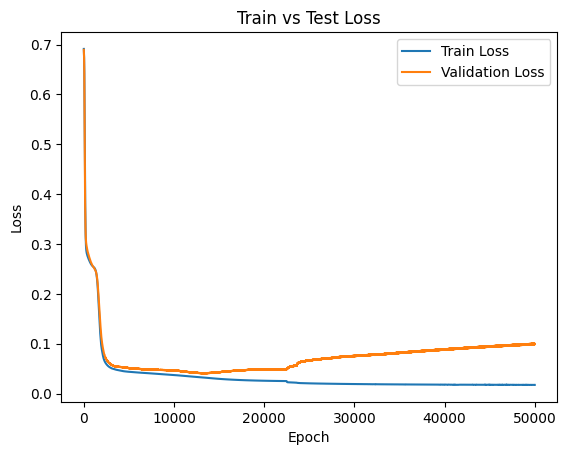

In [4]:
X, y = make_moons(n_samples=500, noise=0.2, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
y_train = y_train.reshape(-1, 1)
y_test = y_test.reshape(-1, 1)

# TODO: Instantiate the NumPy MLP
# TODO: Train for multiple epochs
# TODO: Track training loss
# TODO: Compute train and test accuracy
# TODO: Print or plot the results
train_losses = {}
test_losses = {}
model = MLPFromScratch([2, 32, 16, 1])

for epoch in range(50001):
    train_loss = model.train_step(X_train, y_train)
    train_losses[epoch] = train_loss

    y_test_pred = model.forward(X_test)
    test_loss = model.compute_loss(y_test, y_test_pred)
    test_losses[epoch] = test_loss

    if epoch % 10 == 0:

        y_train_pred = model.forward(X_train)

        train_acc = np.mean((y_train_pred > 0.5) == y_train)

        test_acc = np.mean((y_test_pred > 0.5) == y_test)

        print(

            f"Epoch {epoch}, "

            f"train loss: {train_loss:.4f}, "

            f"test loss: {test_loss:.4f}, "

            f"train acc: {train_acc:.4f}, "

            f"test acc: {test_acc:.4f}"

        )

plt.plot(list(train_losses.keys()), list(train_losses.values()), label="Train Loss")

plt.plot(list(test_losses.keys()), list(test_losses.values()), label="Validation Loss")

plt.legend()

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Train vs Test Loss")

plt.show()


### 2.4 Visualize Decision Boundary

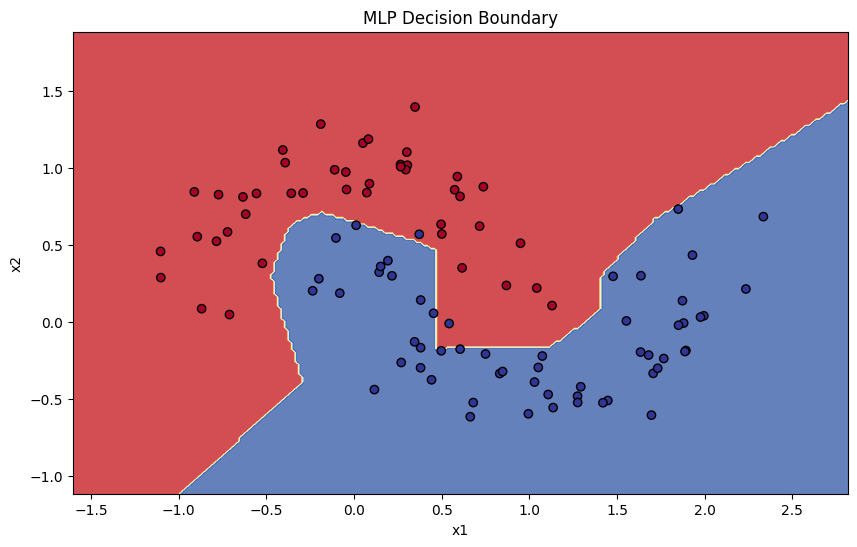

In [5]:
def plot_decision_boundary(model, X, y):
    # 1. Define the boundaries of the plot
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    
    # 2. Create a meshgrid of points with a small step size
    h = 0.02  # Step size
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    
    # 3. Predict the class for every point in the meshgrid
    # We flatten the grid to (N, 2) for the forward pass
    grid_points = np.c_[xx.ravel(), yy.ravel()]
    Z = model.forward(grid_points)
    
    # 4. Convert probabilities to binary classes (0 or 1)
    Z = (Z > 0.5).astype(int)
    Z = Z.reshape(xx.shape)
    
    # 5. Plot the filled contours (the boundary)
    plt.figure(figsize=(10, 6))
    plt.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.RdYlBu)
    
    # 6. Overlay the original data points
    plt.scatter(X[:, 0], X[:, 1], c=y.ravel(), edgecolors='k', cmap=plt.cm.RdYlBu)
    
    plt.xlabel('x1')
    plt.ylabel('x2')
    plt.title('MLP Decision Boundary')
    plt.show()

# Use it like this:
plot_decision_boundary(model, X_test, y_test)

### 2.5 Gradient Checking (Bonus)

In [6]:
def gradient_check(model, X, y, epsilon=1e-7):
    """Compare analytical and numerical gradients."""
    # TODO: Run forward/backward to get analytical gradients
    # TODO: Perturb parameters one at a time
    # TODO: Compute finite-difference approximations
    # TODO: Compare analytical vs numerical gradients
    raise NotImplementedError


# TODO: Optionally run gradient_check(...) on a small subset

## Task 3: MLP with PyTorch

Learning objectives:
- Learn the PyTorch API (`nn.Module`, `optim`, `DataLoader`)
- Compare different regularization methods
- Understand the effect of network depth and width

In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


### 3.1 Setup and Model

In [8]:
# Data
X, y = make_moons(n_samples=1000, noise=0.2, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train_t = torch.FloatTensor(X_train).to(device)
y_train_t = torch.FloatTensor(y_train).unsqueeze(1).to(device)
X_test_t = torch.FloatTensor(X_test).to(device)
y_test_t = torch.FloatTensor(y_test).unsqueeze(1).to(device)

train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)


class TorchMLP(nn.Module):
    def __init__(self, input_dim=2, hidden_dims=[128, 128, 128], output_dim=1, dropout=0.0):
        """MLP with configurable hidden layers and optional dropout."""
        super().__init__()
        layers = []
        prev_dim = input_dim

        for dimension in hidden_dims:
            layers.append(nn.Linear(prev_dim, dimension))
            layers.append(nn.ReLU())
            prev_dim = dimension

        # the last layer
        layers.append(nn.Linear(prev_dim, output_dim))
        layers.append(nn.Sigmoid())

        self.net = nn.Sequential(*layers)

    def forward(self, x):
        for layer in self.net:
            x = layer(x)
        return x

### 3.2 Training Function

In [9]:
def train_model(model, train_loader, X_test_t, y_test_t, lr=0.001, weight_decay=0.0, epochs=200):
    """Train the model and track metrics.

    Returns:
        Dictionary with train_losses, test_losses, train_accs, test_accs.
    """
    loss_func = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    train_losses = []
    test_losses = []
    train_accs = []
    test_accs = []

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for X_batch, y_batch in train_loader:
            y_pred = model(X_batch)
            loss = loss_func(y_pred, y_batch)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            batch_size = y_batch.size(0)
            running_loss += loss.item() * batch_size
            correct += ((y_pred > 0.5) == y_batch).sum().item()
            total += batch_size

        train_losses.append(running_loss / total)
        train_accs.append(correct / total)

        model.eval()
        with torch.no_grad():
            y_test_pred = model(X_test_t)
            test_loss = loss_func(y_test_pred, y_test_t).item()
            test_acc = ((y_test_pred > 0.5) == y_test_t).float().mean().item()

        test_losses.append(test_loss)
        test_accs.append(test_acc)

    return {
        "train_losses": train_losses,
        "test_losses": test_losses,
        "train_accs": train_accs,
        "test_accs": test_accs,
    }


### 3.3 Regularization Comparison

Baseline final train acc: 0.9775 final test acc: 0.9750000238418579 final test loss: 0.05483265221118927
L2 final train acc: 0.965 final test acc: 0.9850000143051147 final test loss: 0.07729901373386383
Dropout final train acc: 0.97625 final test acc: 0.9700000286102295 final test loss: 0.05588378757238388
L2 + Dropout final train acc: 0.965 final test acc: 0.9800000190734863 final test loss: 0.07954005897045135
Small final train acc: 0.96125 final test acc: 0.9750000238418579 final test loss: 0.10371092706918716


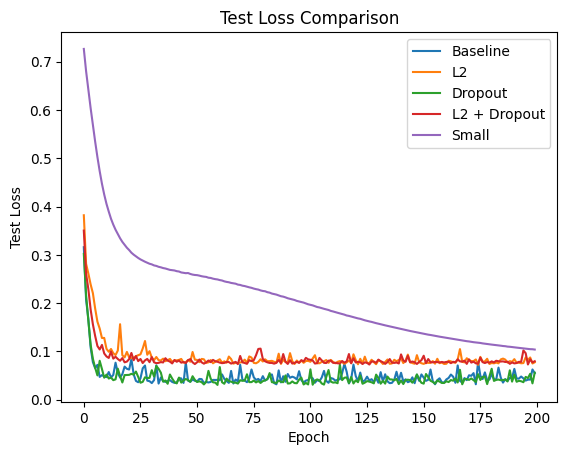

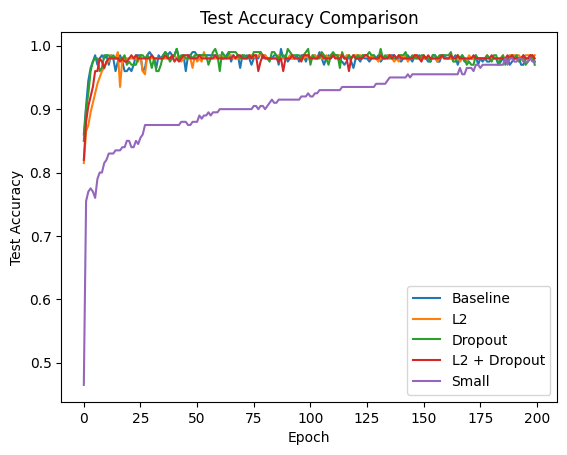

In [ ]:
configs = {
    "Baseline": {"hidden_dims": [128, 128, 128], "dropout": 0.0, "weight_decay": 0.0},
    "L2": {"hidden_dims": [128, 128, 128], "dropout": 0.0, "weight_decay": 0.01},
    "Dropout": {"hidden_dims": [128, 128, 128], "dropout": 0.3, "weight_decay": 0.0},
    "L2 + Dropout": {"hidden_dims": [128, 128, 128], "dropout": 0.3, "weight_decay": 0.01},
    "Small": {"hidden_dims": [16], "dropout": 0.0, "weight_decay": 0.0},
}

results = {}
for name, cfg in configs.items():

    model = TorchMLP(
        hidden_dims=cfg["hidden_dims"],
        dropout=cfg["dropout"]
    )

    results[name] = train_model(
        model,
        train_loader,
        X_test_t,
        y_test_t,
        lr=0.001,
        weight_decay=cfg["weight_decay"],
        epochs=200
    )

for name, metrics in results.items():
    print(
        name,
        "final train acc:", metrics["train_accs"][-1],
        "final test acc:", metrics["test_accs"][-1],
        "final test loss:", metrics["test_losses"][-1],
    )

plt.figure()
for name, metrics in results.items():
    plt.plot(metrics["test_losses"], label=name)

plt.xlabel("Epoch")
plt.ylabel("Test Loss")
plt.title("Test Loss Comparison")
plt.legend()
plt.show()

plt.figure()
for name, metrics in results.items():
    plt.plot(metrics["test_accs"], label=name)

plt.xlabel("Epoch")
plt.ylabel("Test Accuracy")
plt.title("Test Accuracy Comparison")
plt.legend()
plt.show()

### 3.4 Depth vs. Width

Wide & Shallow final train acc: 0.9775 final test acc: 0.9900000095367432 final test loss: 0.04066431149840355
Medium final train acc: 0.97375 final test acc: 0.9900000095367432 final test loss: 0.040599144995212555
Deep & Narrow final train acc: 0.975 final test acc: 0.9800000190734863 final test loss: 0.04361410439014435


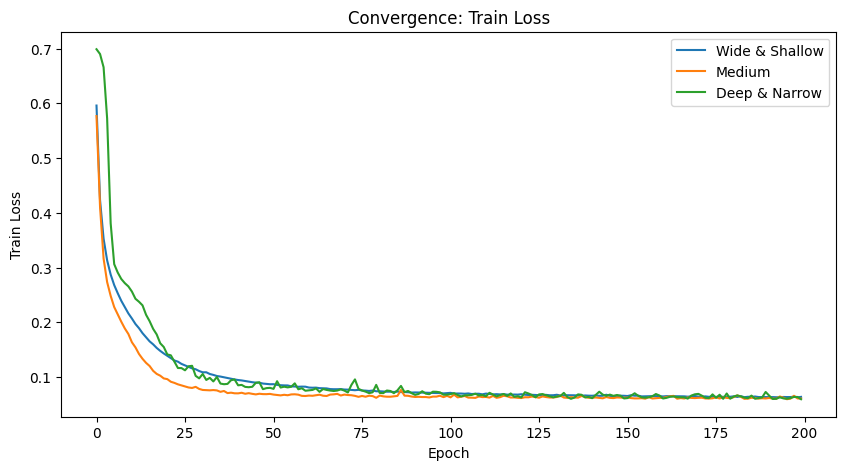

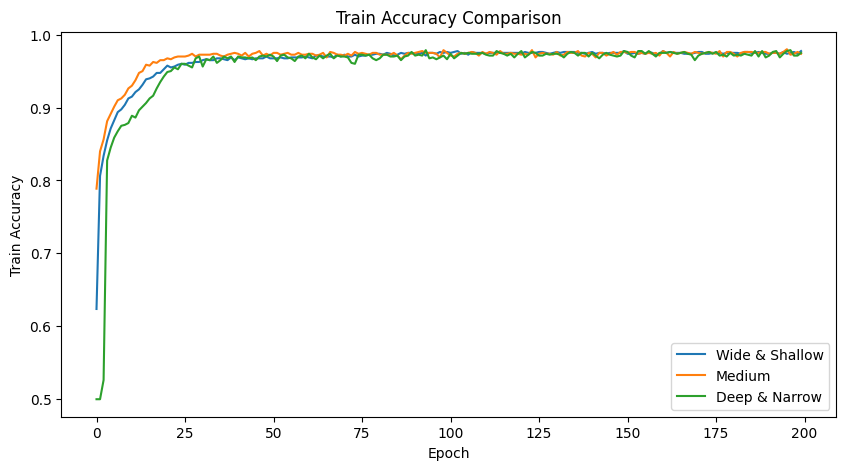

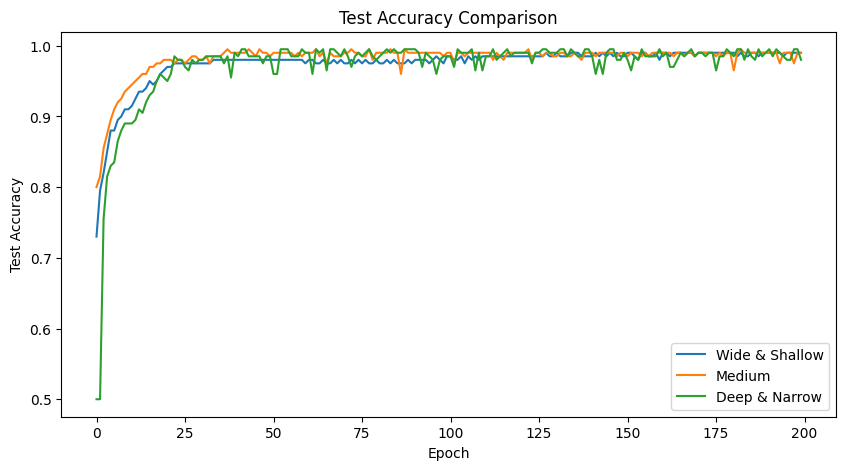

In [11]:
# Compare architectures with roughly similar parameter counts
arch_configs = {
    "Wide & Shallow": [256],
    "Medium": [64, 64],
    "Deep & Narrow": [16, 16, 16, 16, 16],
}

arch_results = {}

for name, hidden_dims in arch_configs.items():
    model = TorchMLP(
        hidden_dims=hidden_dims,
        dropout=0.0
    ).to(device)

    arch_results[name] = train_model(
        model,
        train_loader,
        X_test_t,
        y_test_t,
        lr=0.001,
        weight_decay=0.0,
        epochs=200
    )

# Print final metrics
for name, metrics in arch_results.items():
    print(
        name,
        "final train acc:", metrics["train_accs"][-1],
        "final test acc:", metrics["test_accs"][-1],
        "final test loss:", metrics["test_losses"][-1],
    )

# Plot train loss = convergence
plt.figure(figsize=(10, 5))
for name, metrics in arch_results.items():
    plt.plot(metrics["train_losses"], label=name)

plt.xlabel("Epoch")
plt.ylabel("Train Loss")
plt.title("Convergence: Train Loss")
plt.legend()
plt.show()

# Plot train accuracy
plt.figure(figsize=(10, 5))
for name, metrics in arch_results.items():
    plt.plot(metrics["train_accs"], label=name)

plt.xlabel("Epoch")
plt.ylabel("Train Accuracy")
plt.title("Train Accuracy Comparison")
plt.legend()
plt.show()

# Plot test accuracy
plt.figure(figsize=(10, 5))
for name, metrics in arch_results.items():
    plt.plot(metrics["test_accs"], label=name)

plt.xlabel("Epoch")
plt.ylabel("Test Accuracy")
plt.title("Test Accuracy Comparison")
plt.legend()
plt.show()

### 3.5 Reflection

**TODO:** Compare the PyTorch implementation to the NumPy version in terms of code complexity and training speed.

**TODO:** State which regularization approach worked best and why.

**TODO:** Describe the tradeoffs between deep-narrow and wide-shallow architectures.